In [1]:
from turtledemo.chaos import plot
!pip install pandas numpy matplotlib


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from IPython.display import display

In [19]:
# 1. Define the file path
file_path = r'C:\Users\GeorgiaRg\Documents\Paper N50 PM0.1\Stations\Demokritos\actris data\GR0100B.20190101000000.20210527090725.smps.particle_number_size_distribution.pm10.1y.1h.GR05L_SMPS-TROPOS-TSI.GR05L__NRT_SMPS_lev2.lev2.nas'

# ==========================================
# 1. Parse Header & Identify Columns Dynamically
# ==========================================
with open(file_path, 'r') as f:
    header_lines = f.readlines()

num_header_lines = int(header_lines[0].split()[0])
ny = int(header_lines[9].strip())
missing_values = header_lines[11].split()

var_defs = header_lines[12 : 12 + ny]

dp_list = []
mean_cols = []
flag_col = None
pressure_col = None
temp_col = None

for i, var_def in enumerate(var_defs):
    col_idx = i + 1
    var_def_lower = var_def.lower()

    if 'particle_number_size_distribution' in var_def_lower and 'arithmetic mean' in var_def_lower:
        parts = var_def.split(',')
        for part in parts:
            if 'd=' in part.lower():
                dp = float(part.lower().split('d=')[1].replace('nm', '').strip())
                dp_list.append(dp)
                mean_cols.append(col_idx)
                break
    elif 'flag' in var_def_lower:
        flag_col = col_idx
    elif 'pressure' in var_def_lower and 'hpa' in var_def_lower:
        pressure_col = col_idx
    elif 'temperature' in var_def_lower and 'k' in var_def_lower:
        temp_col = col_idx

In [38]:
# ==========================================
# 2. Read and Clean Data
# ==========================================
df = pd.read_csv(file_path, sep=r'\s+', skiprows=num_header_lines, header=None)

# Replace missing value markers with NaN
for i in range(ny):
    col_idx = i + 1
    miss_val = float(missing_values[i])
    df.loc[df[col_idx] == miss_val, col_idx] = np.nan

# Remove flagged rows if flag column exists
if flag_col is not None:
    df_clean = df[df[flag_col] == 0.0].copy()
else:
    df_clean = df.copy()

# Drop rows missing all size distribution data
df_clean = df_clean.dropna(subset=mean_cols, how='all')

# Extract number distribution and force to numeric
dN_dlogDp = df_clean[mean_cols].copy()
dN_dlogDp.columns = dp_list
dN_dlogDp = dN_dlogDp.apply(pd.to_numeric, errors='coerce')

In [39]:
# ==========================================
# 3. Apply STP Correction
# ==========================================

# 1. Handle Pressure Column
if pressure_col is not None:
    df_clean[pressure_col] = pd.to_numeric(df_clean[pressure_col], errors='coerce')
    df_clean[pressure_col] = df_clean[pressure_col].fillna(1013.25)
else:
    print("Warning: Could not find Pressure column. Using standard pressure (1013.25 hPa).")
    pressure_col = 'Pressure_hPa_Standard'
    df_clean[pressure_col] = 1013.25

# 2. Handle Temperature Column (Original in Celsius)
if temp_col is not None:
    df_clean[temp_col] = pd.to_numeric(df_clean[temp_col], errors='coerce')
    temp_kelvin = df_clean[temp_col] + 273.15
    temp_kelvin = temp_kelvin.fillna(273.15)
else:
    print("Warning: Could not find Temperature column. Using standard temperature (273.15 K).")
    temp_col = 'Temperature_C_Standard'
    df_clean[temp_col] = 25.0
    temp_kelvin = pd.Series(273.15, index=df_clean.index)

# Adapted STP formula
STP_factor = (1013.25 / df_clean[pressure_col]) * (temp_kelvin / 273.15)
df_clean['STP_factor'] = STP_factor

# FIX: Create a new variable to prevent double-correction if cell is re-run
dN_dlogDp_STP = dN_dlogDp.multiply(STP_factor, axis=0)
print("STP applied successfully.")

# Create the summary DataFrame to verify the calculations
stp_summary = pd.DataFrame({
        'Pressure_actual (hPa)': df_clean[pressure_col],
        'Temp_original (C)': df_clean[temp_col],
        'Temp_used (K)': temp_kelvin,
        'Calculated STP Factor': df_clean['STP_factor']
})

# Display the summary dataframe
display(stp_summary)

STP applied successfully.


,Pressure_actual (hPa),Temp_original (C),Temp_used (K),Calculated STP Factor
0,974.816667,24.293333,297.443333,1.131870
1,974.658333,24.279167,297.429167,1.132000
2,974.725000,24.302500,297.452500,1.132012
3,975.058333,24.356667,297.506667,1.131831
4,975.158333,25.073333,298.223333,1.134441
...,...,...,...,...
8755,1013.250000,18.669091,291.819091,1.068347
8756,1013.250000,18.017273,291.167273,1.065961
8757,1013.250000,17.393000,290.543000,1.063676
8758,1013.250000,16.680000,289.830000,1.061065


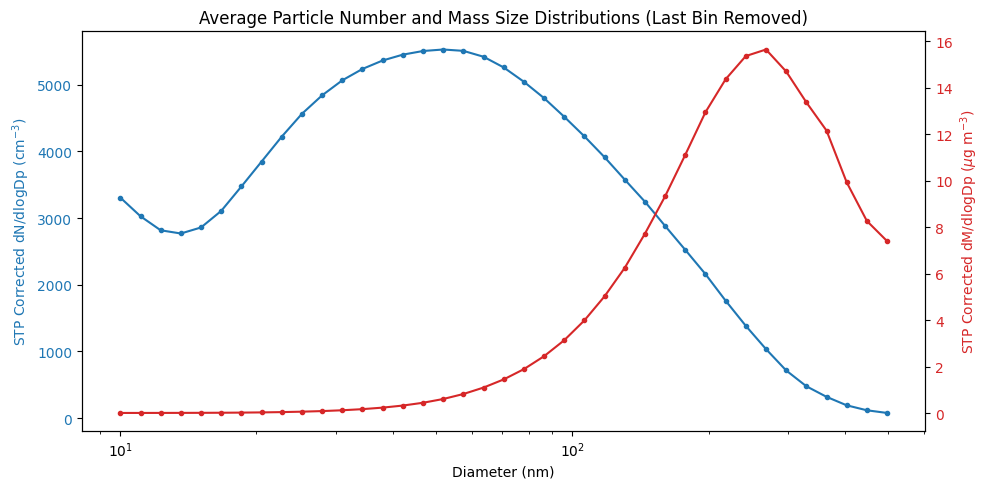

In [43]:
# ==========================================
# 4. Compute Bin Boundaries & Mass Distribution
# ==========================================

# FIX: Drop the last size bin to remove the amplified noise artifact
dp_list_trimmed = dp_list[:-1]
dN_dlogDp_STP_trimmed = dN_dlogDp_STP.iloc[:, :-1]

density = 1.5
mid_D = np.array(dp_list_trimmed, dtype=float).flatten()

# Calculate exact logarithmic bin widths (dlogDp)
log_dp = np.log10(mid_D)
avg_diff = np.mean(np.diff(log_dp))

D_bound = np.full(mid_D.shape[0] + 1, np.nan)
for i in range(1, (len(D_bound) - 1)):
    D_bound[i] = 10 ** (0.5 * (np.log10(mid_D[i]) + np.log10(mid_D[i-1])))

D_bound[0] = 10 ** (np.log10(mid_D[0]) - 0.5 * avg_diff)
D_bound[-1] = 10 ** (np.log10(mid_D[-1]) + 0.5 * avg_diff)

D_low = D_bound[0:-1]
D_high = D_bound[1:]
dlogDp = np.log10(D_high) - np.log10(D_low)

# Calculate volume factor and dM/dlogDp
volume_factor = density * (np.pi / 6.0) * (mid_D ** 3) * 1e-9

# Use the trimmed STP corrected variable
dM_dlogDp = dN_dlogDp_STP_trimmed.multiply(volume_factor, axis=1)

# Explicitly multiply along columns and use min_count=1 to preserve NaNs
dM_total = dM_dlogDp.multiply(dlogDp, axis=1)
df_clean['Total_Mass_ug_m3'] = dM_total.sum(axis=1, min_count=1)

# ==========================================
# 5. Visualization (Updated for trimmed data)
# ==========================================
mean_dN = dN_dlogDp_STP_trimmed.mean(axis=0)
mean_dM = dM_dlogDp.mean(axis=0)

fig, ax1 = plt.subplots(figsize=(10, 5), dpi=100)

color = 'tab:blue'
ax1.set_xlabel('Diameter (nm)')
ax1.set_ylabel(r'STP Corrected dN/dlogDp (cm$^{-3}$)', color=color)
ax1.plot(mid_D, mean_dN, color=color, marker='.', linestyle='-', label='Number')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xscale('log')

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel(r'STP Corrected dM/dlogDp ($\mu$g m$^{-3}$)', color=color)
ax2.plot(mid_D, mean_dM, color=color, marker='.', linestyle='-', label='Mass')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Average Particle Number and Mass Size Distributions (Last Bin Removed)')
fig.tight_layout()
plt.show()

In [44]:
# ==========================================
# 4.5 Calculate N10, PM0.1, and PM1
# ==========================================

# Use robust column-wise multiplication with the trimmed data
dN = dN_dlogDp_STP_trimmed.multiply(dlogDp, axis=1)
dM = dM_dlogDp.multiply(dlogDp, axis=1)

# Create boolean masks for our specific diameter ranges
mask_N10 = mid_D >= 10.0
mask_PM01 = mid_D <= 100.0
mask_PM1 = mid_D <= 1000.0

# Calculate metrics with min_count=1 to preserve missing data
df_clean['N10_cm3'] = dN.loc[:, mask_N10].sum(axis=1, min_count=1)
df_clean['PM0.1_ug_m3'] = dM.loc[:, mask_PM01].sum(axis=1, min_count=1)
df_clean['PM1_ug_m3'] = dM.loc[:, mask_PM1].sum(axis=1, min_count=1)

print("Calculated N10, PM0.1, and PM1 successfully (with last bin removed).")

# Preview the newly calculated metrics
display(df_clean[['Total_Mass_ug_m3', 'N10_cm3', 'PM0.1_ug_m3', 'PM1_ug_m3']])

Calculated N10, PM0.1, and PM1 successfully (with last bin removed).


,Total_Mass_ug_m3,N10_cm3,PM0.1_ug_m3,PM1_ug_m3
0,3.775898,4176.142334,0.416063,3.775898
1,3.856397,4018.849582,0.366549,3.856397
2,4.159531,3628.099095,0.310451,4.159531
3,3.496265,3222.947992,0.250088,3.496265
4,3.653058,3092.255484,0.188582,3.653058
...,...,...,...,...
8755,7.816361,9121.285549,1.063562,7.816361
8756,6.915188,7519.398329,0.899845,6.915188
8757,7.179391,6116.947239,0.862477,7.179391
8758,6.163047,4311.457602,0.641297,6.163047


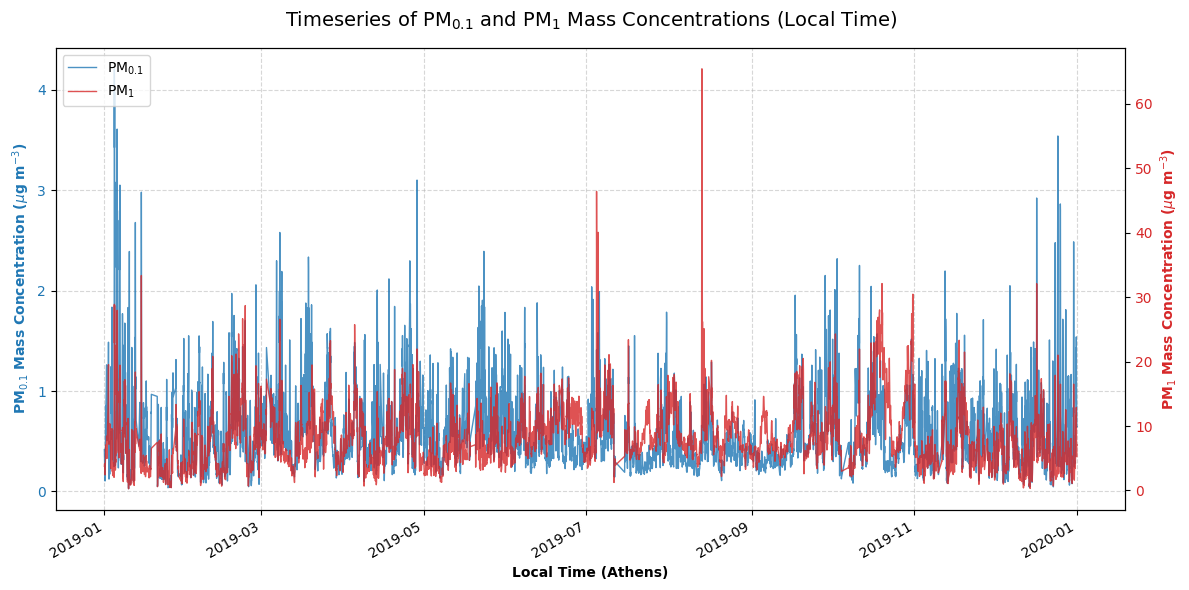

,Datetime_UTC,Datetime_Local,PM0.1_ug_m3,PM1_ug_m3
0,2019-01-01 00:00:00.000000,2019-01-01 02:00:00+02:00,0.416063,3.775898
1,2019-01-01 01:00:00.028800,2019-01-01 03:00:00.028800+02:00,0.366549,3.856397
2,2019-01-01 01:59:59.971200,2019-01-01 03:59:59.971200+02:00,0.310451,4.159531
3,2019-01-01 03:00:00.000000,2019-01-01 05:00:00+02:00,0.250088,3.496265
4,2019-01-01 04:00:00.028800,2019-01-01 06:00:00.028800+02:00,0.188582,3.653058
...,...,...,...,...
8755,2019-12-31 19:00:00.028800,2019-12-31 21:00:00.028800+02:00,1.063562,7.816361
8756,2019-12-31 19:59:59.971200,2019-12-31 21:59:59.971200+02:00,0.899845,6.915188
8757,2019-12-31 21:00:00.000000,2019-12-31 23:00:00+02:00,0.862477,7.179391
8758,2019-12-31 22:00:00.028800,2020-01-01 00:00:00.028800+02:00,0.641297,6.163047


In [45]:
# ==========================================
# 5. Timeseries Visualization (Local Time)
# ==========================================

# 1. Calculate UTC Datetime from EBAS reference point
reference_date = pd.to_datetime('2019-01-01')
df_clean['Datetime_UTC'] = reference_date + pd.to_timedelta(df_clean[0], unit='D')

# 2. Localize to UTC, then convert to Athens Local Time
# 'Europe/Athens' automatically handles EET (UTC+2) and EEST (UTC+3) daylight savings
df_clean['Datetime_Local'] = df_clean['Datetime_UTC'].dt.tz_localize('UTC').dt.tz_convert('Europe/Athens')

# Sort chronologically
df_clean = df_clean.sort_values('Datetime_Local')

# ==========================================
# Plotting
# ==========================================
fig, ax1 = plt.subplots(figsize=(12, 6), dpi=100)

# Plot PM0.1 on the left y-axis
color1 = 'tab:blue'
ax1.set_xlabel('Local Time (Athens)', fontweight='bold')
ax1.set_ylabel(r'PM$_{0.1}$ Mass Concentration ($\mu$g m$^{-3}$)', color=color1, fontweight='bold')
ax1.plot(df_clean['Datetime_Local'], df_clean['PM0.1_ug_m3'], color=color1, linewidth=1, alpha=0.8, label='PM$_{0.1}$')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, linestyle='--', alpha=0.5)

# Create a second y-axis that shares the same x-axis
ax2 = ax1.twinx()

# Plot PM1 on the right y-axis
color2 = 'tab:red'
ax2.set_ylabel(r'PM$_{1}$ Mass Concentration ($\mu$g m$^{-3}$)', color=color2, fontweight='bold')
ax2.plot(df_clean['Datetime_Local'], df_clean['PM1_ug_m3'], color=color2, linewidth=1, alpha=0.8, label='PM$_{1}$')
ax2.tick_params(axis='y', labelcolor=color2)

# Format the x-axis to look nice with dates
fig.autofmt_xdate()

# Set the title and adjust layout
plt.title('Timeseries of PM$_{0.1}$ and PM$_{1}$ Mass Concentrations (Local Time)', fontsize=14, pad=15)
fig.tight_layout()

# Add a combined legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

plt.show()

# Display a preview of the time conversion
df_clean[['Datetime_UTC', 'Datetime_Local', 'PM0.1_ug_m3', 'PM1_ug_m3']]